In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('dataset.csv')
df= df.drop(columns=['Test Sample','Experimental Run'], axis=1)

In [3]:
df.columns

Index(['Infill Density (%)', 'Nozzle Temperature (C)', 'Infill Pattern',
       'Mean Tensile Stress (MPa)', 'Tensile Stress SD (MPa)'],
      dtype='object')

# Gausian Noise

In [4]:
import pandas as pd
import numpy as np

def augment_data_vectorized(df, n_synthetic=10):
    """
    Expands the dataset by generating synthetic samples using Gaussian noise.
    
    Args:
        df: The original DataFrame.
        n_synthetic: Number of synthetic points to generate per original row.
    """
    # 1. Repeat each row n_synthetic times
    df_aug = df.loc[df.index.repeat(n_synthetic)].reset_index(drop=True)
    
    # 2. Generate Gaussian noise: Mean = 0, SD = 1
    # We multiply this by the actual SD from the table to scale the noise
    noise = np.random.normal(size=len(df_aug))
    
    # 3. Apply the noise: New Value = Mean + (Noise * SD)
    df_aug['Tensile Stress (Augmented)'] = (
        df_aug['Mean Tensile Stress (MPa)'] + 
        (noise * df_aug['Tensile Stress SD (MPa)'])
    ).round(3)
    
    # 4. Shuffle the dataset so the model doesn't learn the order of experiments
    return df_aug.sample(frac=1).reset_index(drop=True)

# Execute the augmentation
# If you have 33 rows, this will result in 99 rows
augmented_df = augment_data_vectorized(df, n_synthetic=3)

# Display a preview
print(f"Dataset expanded from {len(df)} to {len(augmented_df)} rows.")
print(augmented_df[['Infill Pattern', 'Mean Tensile Stress (MPa)', 'Tensile Stress (Augmented)']].head(20))

Dataset expanded from 33 to 99 rows.
   Infill Pattern  Mean Tensile Stress (MPa)  Tensile Stress (Augmented)
0            Grid                      13.87                      13.981
1        Triangle                       9.70                       9.464
2        Triangle                      10.54                       9.880
3   Triangle-Hexa                      10.70                      10.813
4            Grid                      10.70                      10.782
5   Triangle-Hexa                      14.44                      14.148
6   Triangle-Hexa                      14.16                      14.963
7            Grid                      13.67                      12.743
8            Grid                       8.42                       8.715
9   Triangle-Hexa                      17.34                      18.338
10       Triangle                      12.68                      11.607
11           Grid                       8.42                       8.598
12           G

In [5]:
augmented_df.columns

Index(['Infill Density (%)', 'Nozzle Temperature (C)', 'Infill Pattern',
       'Mean Tensile Stress (MPa)', 'Tensile Stress SD (MPa)',
       'Tensile Stress (Augmented)'],
      dtype='object')

In [6]:
augmented_df

,Infill Density (%),Nozzle Temperature (C),Infill Pattern,Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented)
0,60.00,240.00,Grid,13.87,0.44,13.981
1,45.87,225.86,Triangle,9.70,0.28,9.464
2,60.00,220.00,Triangle,10.54,0.37,9.880
3,40.00,240.00,Triangle-Hexa,10.70,0.38,10.813
4,60.00,220.00,Grid,10.70,0.39,10.782
...,...,...,...,...,...,...
94,60.00,240.00,Triangle,11.74,0.34,11.288
95,80.00,240.00,Grid,17.44,0.82,18.776
96,60.00,220.00,Triangle-Hexa,12.13,0.40,12.672
97,80.00,240.00,Grid,17.44,0.82,17.711


In [7]:
# one-hot encode the 'Infill Pattern' column
df_encoded = pd.get_dummies(augmented_df, columns=['Infill Pattern'])
df_encoded['Infill Pattern_Grid'] = df_encoded['Infill Pattern_Grid'].astype(int)
df_encoded['Infill Pattern_Triangle'] = df_encoded['Infill Pattern_Triangle'].astype(int)
df_encoded['Infill Pattern_Triangle-Hexa'] = df_encoded['Infill Pattern_Triangle-Hexa'].astype(int)



In [8]:
df_encoded[['Infill Pattern_Grid', 'Infill Pattern_Triangle', 'Infill Pattern_Triangle-Hexa']].head(3)

,Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa
0,1,0,0
1,0,1,0
2,0,1,0


# baseline corrilation

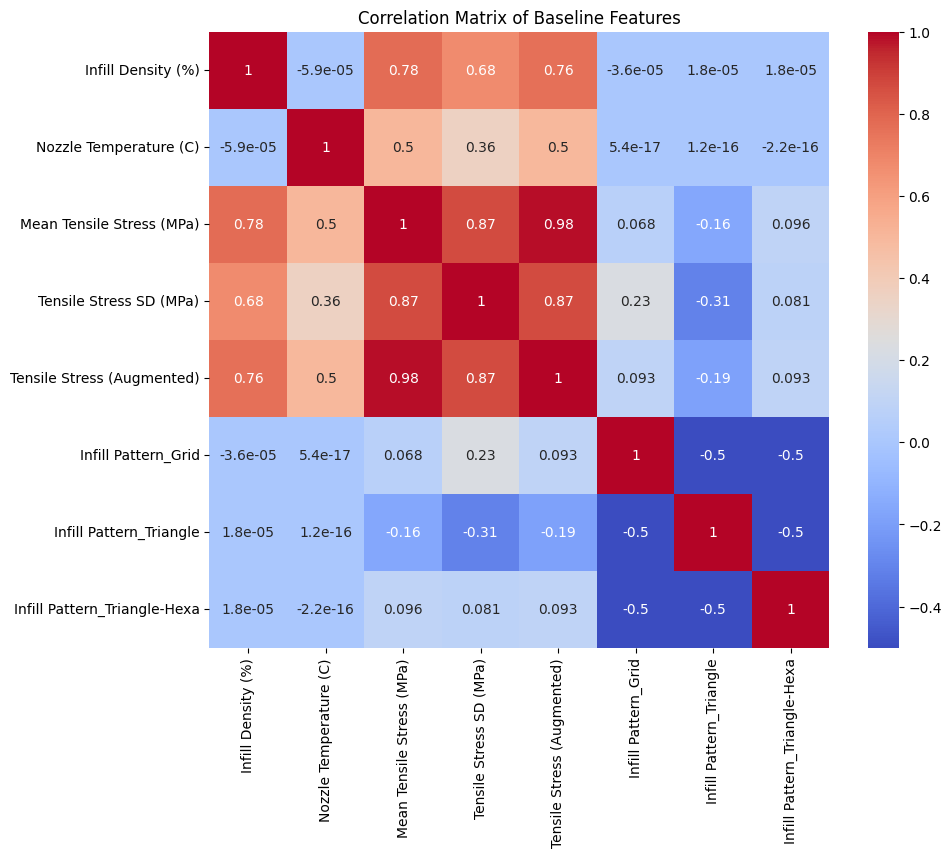

In [9]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Baseline Features')
plt.show()

In [10]:
df_encoded.columns

Index(['Infill Density (%)', 'Nozzle Temperature (C)',
       'Mean Tensile Stress (MPa)', 'Tensile Stress SD (MPa)',
       'Tensile Stress (Augmented)', 'Infill Pattern_Grid',
       'Infill Pattern_Triangle', 'Infill Pattern_Triangle-Hexa'],
      dtype='object')

## Effective Area ($A_{eff}$)

In [11]:
# Create a mapping for the Geometry Factor
# Note: Since your data is one-hot encoded, we multiply by the column indicator
df_encoded['Effective Load-Bearing Area (Aeff)'] = df_encoded['Infill Density (%)'] * (
    (df_encoded['Infill Pattern_Triangle-Hexa'] * 1.0) +
    (df_encoded['Infill Pattern_Triangle'] * 0.85) +
    (df_encoded['Infill Pattern_Grid'] * 0.70)
)

In [12]:
df_encoded

,Infill Density (%),Nozzle Temperature (C),Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented),Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa,Effective Load-Bearing Area (Aeff)
0,60.00,240.00,13.87,0.44,13.981,1,0,0,42.0000
1,45.87,225.86,9.70,0.28,9.464,0,1,0,38.9895
2,60.00,220.00,10.54,0.37,9.880,0,1,0,51.0000
3,40.00,240.00,10.70,0.38,10.813,0,0,1,40.0000
4,60.00,220.00,10.70,0.39,10.782,1,0,0,42.0000
...,...,...,...,...,...,...,...,...,...
94,60.00,240.00,11.74,0.34,11.288,0,1,0,51.0000
95,80.00,240.00,17.44,0.82,18.776,1,0,0,56.0000
96,60.00,220.00,12.13,0.40,12.672,0,0,1,60.0000
97,80.00,240.00,17.44,0.82,17.711,1,0,0,56.0000


## polymer difusin rate

In [13]:
# 1. Define Constants
Ea = 68000  # Activation Energy for PA6 (J/mol)
R = 8.314    # Gas Constant
T_kelvin = df_encoded['Nozzle Temperature (C)'] + 273.15

# 2. Calculate Polymer Diffusion Rate
# We can set D0 = 1 for relative comparison
df_encoded['Diffusion Rate'] = np.exp(-Ea / (R * T_kelvin))

# 3. Normalize it so it stays on a 0-1 scale like your other features
df_encoded['Diffusion_Rate_Normalized'] = (df_encoded['Diffusion Rate'] - df_encoded['Diffusion Rate'].min()) / \
                                          (df_encoded['Diffusion Rate'].max() - df_encoded['Diffusion Rate'].min())

In [14]:
df_encoded[['Mean Tensile Stress (MPa)','Tensile Stress SD (MPa)', 'Tensile Stress (Augmented)']]

,Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented)
0,13.87,0.44,13.981
1,9.70,0.28,9.464
2,10.54,0.37,9.880
3,10.70,0.38,10.813
4,10.70,0.39,10.782
...,...,...,...
94,11.74,0.34,11.288
95,17.44,0.82,18.776
96,12.13,0.40,12.672
97,17.44,0.82,17.711


# physics augmented corrilation

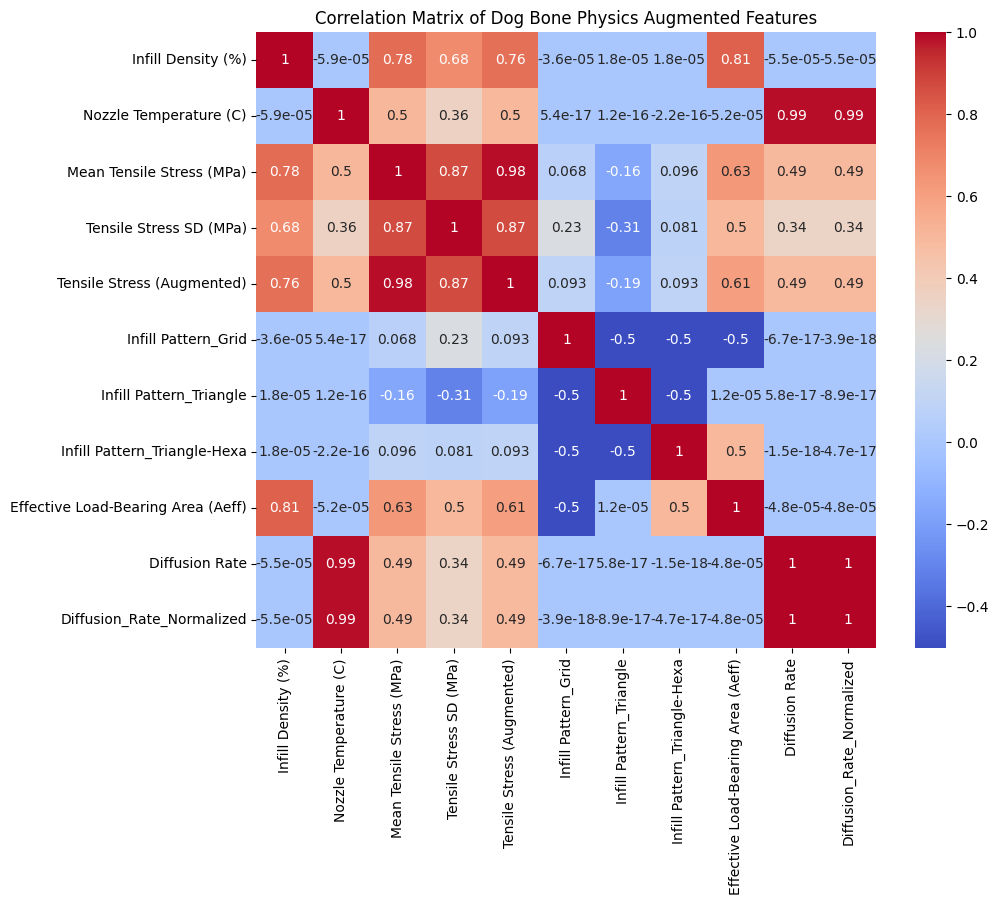

In [15]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Dog Bone Physics Augmented Features')
plt.show()

In [16]:
df_encoded

,Infill Density (%),Nozzle Temperature (C),Mean Tensile Stress (MPa),Tensile Stress SD (MPa),Tensile Stress (Augmented),Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa,Effective Load-Bearing Area (Aeff),Diffusion Rate,Diffusion_Rate_Normalized
0,60.00,240.00,13.87,0.44,13.981,1,0,0,42.0000,1.196421e-07,0.367799
1,45.87,225.86,9.70,0.28,9.464,0,1,0,38.9895,7.616198e-08,0.087035
2,60.00,220.00,10.54,0.37,9.880,0,1,0,51.0000,6.268352e-08,0.000000
3,40.00,240.00,10.70,0.38,10.813,0,0,1,40.0000,1.196421e-07,0.367799
4,60.00,220.00,10.70,0.39,10.782,1,0,0,42.0000,6.268352e-08,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
94,60.00,240.00,11.74,0.34,11.288,0,1,0,51.0000,1.196421e-07,0.367799
95,80.00,240.00,17.44,0.82,18.776,1,0,0,56.0000,1.196421e-07,0.367799
96,60.00,220.00,12.13,0.40,12.672,0,0,1,60.0000,6.268352e-08,0.000000
97,80.00,240.00,17.44,0.82,17.711,1,0,0,56.0000,1.196421e-07,0.367799


# Features defination

In [17]:
# Physics-Augmented Features

FEATURES_PHYSICS = [
    # 'Infill Density (%)', 
    'Infill Pattern_Grid', 
    'Infill Pattern_Triangle', 
    'Infill Pattern_Triangle-Hexa', 
    'Effective Load-Bearing Area (Aeff)',
    'Diffusion_Rate_Normalized'
]


# Baseline Features (Standard Engineering)
FEATURES_BASE = [
    'Infill Density (%)', 
    'Nozzle Temperature (C)', 
    'Infill Pattern_Grid', 
    'Infill Pattern_Triangle', 
    'Infill Pattern_Triangle-Hexa'
]

# Defining the target
target_augmented = 'Tensile Stress (Augmented)'
target_validation = 'Mean Tensile Stress (MPa)'

A dual-target splitting strategy was employed to separate the synthetic training distribution from the physical validation set. While the model was trained on augmented data to capture stochastic process variance , all performance metrics were calculated using the original laboratory-verified means to ensure objective generalizability.

# RF baseline

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target_augmented]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf_base = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train_base, y_train)

y_pred = rf_base.predict(X_test)

rf_r2_base  = r2_score(y_test, y_pred)
rf_mse_base = mean_squared_error(y_test, y_pred)
rf_rmse_base = np.sqrt(rf_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
rf_acc_2_5_base = tolerance_accuracy(y_test.values, y_pred, 0.25)
rf_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)
print(f"=== Random Forest Prediction (Test) for BaseLine Features ===")
print(f"R²          : {rf_r2_base:.4f}")
print(f"RMSE        : {rf_rmse_base:.3f} MPa")
print(f"MSE         : {rf_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {rf_acc_2_5_base* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {rf_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {rf_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {rf_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
rf_cv_r2_base = cross_val_score(rf_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for BaseLine Features ===")
print(f"Mean R² : {rf_cv_r2_base.mean():.4f}  (±{rf_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2_base, 4)}")

rf_cv_r2_base = rf_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': rf_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest Prediction (Test) for BaseLine Features ===
R²          : 0.8631
RMSE        : 1.047 MPa
MSE         : 1.0965 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 35.00%
  Engineering    (±0.50 MPa): 55.00%
  Acceptable     (±1.00 MPa): 65.00%
  Upper Bound    (±2.00 MPa): 90.00%

=== KFolf CV Evaluation Marix for BaseLine Features ===
Mean R² : 0.8434  (±0.0382)
Scores  : [0.8653 0.8325 0.773  0.8733 0.8729]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)    0.544578
      Nozzle Temperature (C)    0.342424
     Infill Pattern_Triangle    0.055984
         Infill Pattern_Grid    0.032505
Infill Pattern_Triangle-Hexa    0.024509


# rf physics

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target_augmented]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf_physics = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
rf_physics.fit(X_train_physics, y_train)

y_pred = rf_physics.predict(X_test)

rf_r2_physics  = r2_score(y_test, y_pred)
rf_mse_physics = mean_squared_error(y_test, y_pred)
rf_rmse_physics = np.sqrt(rf_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
rf_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25)
rf_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Random Forest Prediction (Test) for Physics Augmented Features ===")
print(f"R²          : {rf_r2_physics:.4f}")
print(f"RMSE        : {rf_rmse_physics:.3f} MPa")
print(f"MSE         : {rf_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): { rf_acc_2_5_physics* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {rf_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {rf_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {rf_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
rf_cv_r2_physics = cross_val_score(rf_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics Augmented Features ===")
print(f"Mean R² : {rf_cv_r2_physics.mean():.4f}  (±{rf_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2_physics, 4)}")

rf_cv_r2_physics = rf_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': rf_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== Random Forest Prediction (Test) for Physics Augmented Features ===
R²          : 0.7705
RMSE        : 1.356 MPa
MSE         : 1.8383 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 30.00%
  Engineering    (±0.50 MPa): 50.00%
  Acceptable     (±1.00 MPa): 65.00%
  Upper Bound    (±2.00 MPa): 85.00%

=== KFolf CV Evaluation Marix for Physics Augmented Features ===
Mean R² : 0.7898  (±0.0608)
Scores  : [0.7632 0.7139 0.7503 0.8463 0.8751]

=== Feature Importances (Top 10) ===
                           feature  importance
Effective Load-Bearing Area (Aeff)    0.529349
         Diffusion_Rate_Normalized    0.356381
               Infill Pattern_Grid    0.046171
           Infill Pattern_Triangle    0.041903
      Infill Pattern_Triangle-Hexa    0.026196


In [22]:
rf_cv_r2_physics

np.float64(0.7897643864950586)

In [23]:
print("======== Random Forest =============\n")
print("comparision between baseline and physics augmented predictions\n")
print(f"Baseline R²: {rf_r2_base:.4f}   | Physics-Augmented R²: {rf_r2_physics:.4f}")
print(f"Baseline CV R²: {rf_cv_r2_base:.4f}| Physics-Augmented CV R²: {rf_cv_r2_physics:.4f}")
print(f"Baseline mse: {rf_mse_base: .4f} | Physics-Augmented mse: {rf_mse_physics:.4f}")
print(f"Baseline rmse: {rf_rmse_base: .4f}| Physics-Augmented rmse: {rf_rmse_physics:.4f}")

======== Random Forest =============

comparision between baseline and physics augmented predictions

Baseline R²: 0.8631   | Physics-Augmented R²: 0.7705
Baseline CV R²: 0.8434| Physics-Augmented CV R²: 0.7898
Baseline mse:  1.0965 | Physics-Augmented mse: 1.8383
Baseline rmse:  1.0471| Physics-Augmented rmse: 1.3559


# XGBoost baseline


In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target_augmented]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

xgb_base = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
xgb_base.fit(X_train_base, y_train)

y_pred = xgb_base.predict(X_test)

xgb_r2_base  = r2_score(y_test, y_pred)
xgb_mse_base = mean_squared_error(y_test, y_pred)
xgb_rmse_base = np.sqrt(xgb_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
xgb_acc_2_5_base= tolerance_accuracy(y_test.values, y_pred, 0.25)
xgb_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
xgb_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
xgb_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
xgb_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== XGBoost Prediction (Test) for BaseLine Features ===")
print(f"R²          : {xgb_r2_base:.4f}")
print(f"RMSE        : {xgb_rmse_base:.3f} MPa")
print(f"MSE         : {xgb_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {xgb_acc_2_5_base * 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {xgb_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {xgb_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {xgb_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
xgb_cv_r2_base = cross_val_score(xgb_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Baseline Features ===")
print(f"Mean R² : {xgb_cv_r2_base.mean():.4f}  (±{xgb_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(xgb_cv_r2_base, 4)}")

xgb_cv_r2_base = xgb_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': xgb_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== XGBoost Prediction (Test) for BaseLine Features ===
R²          : 0.8631
RMSE        : 1.047 MPa
MSE         : 1.0965 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 35.00%
  Engineering    (±0.50 MPa): 55.00%
  Acceptable     (±1.00 MPa): 65.00%
  Upper Bound    (±2.00 MPa): 90.00%

=== KFolf CV Evaluation Marix for Baseline Features ===
Mean R² : 0.8434  (±0.0382)
Scores  : [0.8653 0.8325 0.773  0.8733 0.8729]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)    0.544578
      Nozzle Temperature (C)    0.342424
     Infill Pattern_Triangle    0.055984
         Infill Pattern_Grid    0.032505
Infill Pattern_Triangle-Hexa    0.024509


# XGBoost Physics

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target_augmented]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

xgb_physics = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
xgb_physics.fit(X_train_physics, y_train)

y_pred = xgb_physics.predict(X_test)

xgb_r2_physics  = r2_score(y_test, y_pred)
xgb_mse_physics = mean_squared_error(y_test, y_pred)
xgb_rmse_physics = np.sqrt(xgb_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

xgb_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25)
xgb_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
xgb_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
xgb_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
xgb_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== XGBoost Prediction (Test) for Physics Augmented Features ===")
print(f"R²          : {xgb_r2_physics:.4f}")
print(f"RMSE        : {xgb_rmse_physics:.3f} MPa")
print(f"MSE         : {xgb_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {xgb_acc_2_5_physics* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {xgb_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {xgb_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {xgb_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
xgb_cv_r2_physics = cross_val_score(xgb_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics Augmented Features ===")
print(f"Mean R² : {xgb_cv_r2_physics.mean():.4f}  (±{xgb_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(xgb_cv_r2_physics, 4)}")

xgb_cv_r2_physics = xgb_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': xgb_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== XGBoost Prediction (Test) for Physics Augmented Features ===
R²          : 0.7705
RMSE        : 1.356 MPa
MSE         : 1.8383 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 30.00%
  Engineering    (±0.50 MPa): 50.00%
  Acceptable     (±1.00 MPa): 65.00%
  Upper Bound    (±2.00 MPa): 85.00%

=== KFolf CV Evaluation Marix for Physics Augmented Features ===
Mean R² : 0.7898  (±0.0608)
Scores  : [0.7632 0.7139 0.7503 0.8463 0.8751]

=== Feature Importances (Top 10) ===
                           feature  importance
Effective Load-Bearing Area (Aeff)    0.529349
         Diffusion_Rate_Normalized    0.356381
               Infill Pattern_Grid    0.046171
           Infill Pattern_Triangle    0.041903
      Infill Pattern_Triangle-Hexa    0.026196


In [28]:
print("======== Xgboost =============\n")
print("comparision between baseline and physics augmented predictions\n")
print(f"Baseline R²: {xgb_r2_base:.4f}   | Physics-Augmented R²: {xgb_r2_physics:.4f}")
print(f"Baseline CV R²: {xgb_cv_r2_base:.4f}   | Physics-Augmented CV R²: {xgb_cv_r2_physics:.4f}")
print(f"Baseline mse: {xgb_mse_base: .4f} | Physics-Augmented mse: {xgb_mse_physics:.4f}")
print(f"Baseline rmse: {xgb_rmse_base: .4f}| Physics-Augmented rmse: {xgb_rmse_physics:.4f}")

======== Xgboost =============

comparision between baseline and physics augmented predictions

Baseline R²: 0.8631   | Physics-Augmented R²: 0.7705
Baseline CV R²: 0.8434   | Physics-Augmented CV R²: 0.7898
Baseline mse:  1.0965 | Physics-Augmented mse: 1.8383
Baseline rmse:  1.0471| Physics-Augmented rmse: 1.3559


# LightGBM base

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target_augmented]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [30]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb

lgb_base = lgb.LGBMRegressor(
    boosting_type='dart',      # Helps prevent overfitting on small datasets
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=15,             # Keep this low for small N
    max_depth=4,
    feature_fraction=0.8,
    random_state=42,
    verbosity=-1 
)

lgb_base.fit(X_train_base, y_train)

y_pred = lgb_base.predict(X_test)

lgb_r2_base  = r2_score(y_test, y_pred)
lgb_mse_base = mean_squared_error(y_test, y_pred)
lgb_rmse_base = np.sqrt(lgb_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

lgb_acc_2_5_base = tolerance_accuracy(y_test.values, y_pred, 0.25)
lgb_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
lgb_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
lgb_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
lgb_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Light GBM Prediction (Test) for BaseLine Features ===")
print(f"R²          : {lgb_r2_base:.4f}")
print(f"RMSE        : {lgb_rmse_base:.3f} MPa")
print(f"MSE         : {lgb_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {lgb_acc_2_5_base * 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {lgb_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {lgb_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {lgb_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
lgb_cv_r2_base = cross_val_score(lgb_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for BaseLine Features ===")
print(f"Mean R² : {lgb_cv_r2_base.mean():.4f}  (±{lgb_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(lgb_cv_r2_base, 4)}")

lgb_cv_r2_base = lgb_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': lgb_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== Light GBM Prediction (Test) for BaseLine Features ===
R²          : -0.0075
RMSE        : 2.841 MPa
MSE         : 8.0713 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa):  0.00%
  Engineering    (±0.50 MPa):  0.00%
  Acceptable     (±1.00 MPa): 40.00%
  Upper Bound    (±2.00 MPa): 65.00%

=== KFolf CV Evaluation Marix for BaseLine Features ===
Mean R² : 0.5886  (±0.3030)
Scores  : [-0.0075  0.6875  0.7004  0.7212  0.8416]

=== Feature Importances (Top 10) ===
                     feature  importance
      Nozzle Temperature (C)         317
Infill Pattern_Triangle-Hexa         297
          Infill Density (%)         272
     Infill Pattern_Triangle          31
         Infill Pattern_Grid          29


# LGB physics

In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target_augmented]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [32]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb

lgb_physics = lgb.LGBMRegressor(
    boosting_type='dart',      # Helps prevent overfitting on small datasets
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=15,             # Keep this low for small N
    max_depth=4,
    feature_fraction=0.8,
    random_state=42
)

lgb_physics.fit(X_train_physics, y_train)

y_pred = lgb_physics.predict(X_test)

lgb_r2_physics  = r2_score(y_test, y_pred)
lgb_mse_physics = mean_squared_error(y_test, y_pred)
lgb_rmse_physics = np.sqrt(lgb_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

lgb_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25)
lgb_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
lgb_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
lgb_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
lgb_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Light GBM Prediction (Test) for Physics augmented Features ===")
print(f"R²          : {lgb_r2_physics:.4f}")
print(f"RMSE        : {lgb_rmse_physics:.3f} MPa")
print(f"MSE         : {lgb_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): { lgb_acc_2_5_physics* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {lgb_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {lgb_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {lgb_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_physics tscv object
lgb_cv_r2_physics = cross_val_score(lgb_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics augmented Features ===")
print(f"Mean R² : {lgb_cv_r2_physics.mean():.4f}  (±{lgb_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(lgb_cv_r2_physics, 4)}")

lgb_cv_r2_physics = lgb_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': lgb_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== Light GBM Prediction (Test) for Physics augmented Features ===
R²          : 0.4781
RMSE        : 2.045 MPa
MSE         : 4.1811 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 20.00%
  Engineering    (±0.50 MPa): 30.00%
  Acceptable     (±1.00 MPa): 45.00%
  Upper Bound    (±2.00 MPa): 60.00%

=== KFolf CV Evaluation Marix for Physics augmented Features ===
Mean R² : 0.5292  (±0.1634)
Scores  : [0.4781 0.2546 0.5567 0.6065 0.75  ]

=== Feature Importances (Top 10) ===
                           feature  importance
Effective Load-Bearing Area (Aeff)         374
         Diffusion_Rate_Normalized         352
           Infill Pattern_Triangle         177
               Infill Pattern_Grid          24
      Infill Pattern_Triangle-Hexa          13


In [33]:
print("======== LightGBM =============\n")
print("comparision between baseline and physics augmented predictions\n")
print(f"Baseline R²: {lgb_r2_base:.4f}   | Physics-Augmented R²: {lgb_r2_physics:.4f}")
print(f"Baseline CV R²: {lgb_cv_r2_base:.4f}| Physics-Augmented CV R²: {lgb_cv_r2_physics:.4f}")
print(f"Baseline mse: {lgb_mse_base: .4f} | Physics-Augmented mse: {lgb_mse_physics:.4f}")
print(f"Baseline rmse: {lgb_rmse_base: .4f}| Physics-Augmented rmse: {lgb_rmse_physics:.4f}")

======== LightGBM =============

comparision between baseline and physics augmented predictions

Baseline R²: -0.0075   | Physics-Augmented R²: 0.4781
Baseline CV R²: 0.5886| Physics-Augmented CV R²: 0.5292
Baseline mse:  8.0713 | Physics-Augmented mse: 4.1811
Baseline rmse:  2.8410| Physics-Augmented rmse: 2.0448


# catboost base

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target_augmented]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [35]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

from catboost import CatBoostRegressor

cat_base = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    verbose=0,
    random_state=42
)

cat_base.fit(X_train_base, y_train)

y_pred = cat_base.predict(X_test)

cat_r2_base  = r2_score(y_test, y_pred)
cat_mse_base = mean_squared_error(y_test, y_pred)
cat_rmse_base = np.sqrt(cat_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

cat_acc_2_5_base= tolerance_accuracy(y_test.values, y_pred, 0.25)
cat_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
cat_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
cat_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
cat_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== CAT boost Prediction (Test) for Baseline  ===")
print(f"R²          : {cat_r2_base:.4f}")
print(f"RMSE        : {cat_rmse_base:.3f} MPa")
print(f"MSE         : {cat_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {cat_acc_2_5_base* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {cat_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {cat_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {cat_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_base tscv object
cat_cv_r2_base = cross_val_score(cat_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Baseline Features ===")
print(f"Mean R² : {cat_cv_r2_base.mean():.4f}  (±{cat_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(cat_cv_r2_base, 4)}")

cat_cv_r2_base = cat_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': cat_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== CAT boost Prediction (Test) for Baseline  ===
R²          : 0.9802
RMSE        : 0.399 MPa
MSE         : 0.1589 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 30.00%
  Engineering    (±0.50 MPa): 80.00%
  Acceptable     (±1.00 MPa): 100.00%
  Upper Bound    (±2.00 MPa): 100.00%

=== KFolf CV Evaluation Marix for Baseline Features ===
Mean R² : 0.9304  (±0.0419)
Scores  : [0.9801 0.8566 0.9348 0.9584 0.9219]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)   50.769808
      Nozzle Temperature (C)   34.521977
     Infill Pattern_Triangle    6.347632
         Infill Pattern_Grid    4.805258
Infill Pattern_Triangle-Hexa    3.555326


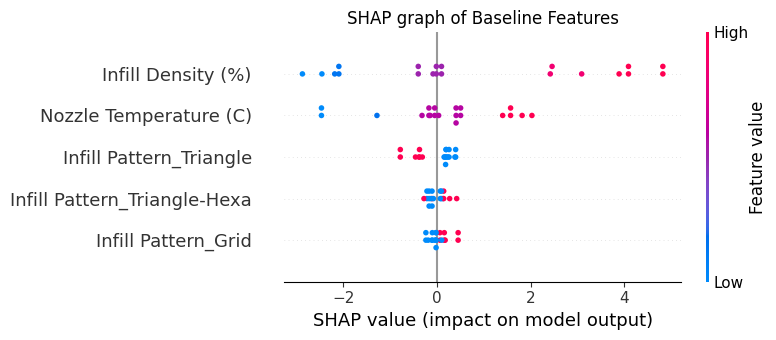

In [36]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer
explainer = shap.TreeExplainer(cat_base)

# 2. Calculate SHAP values for your test set
# Use the actual physics features dataframe
shap_values = explainer.shap_values(X_test)

# 3. Plot the Summary Plot
plt.figure(figsize=(10, 6))
plt.title('SHAP graph of Baseline Features')
shap.summary_plot(shap_values, X_test, feature_names=FEATURES_BASE)



# catboost physics

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target_augmented]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (79, 5)
Shape of X_test: (20, 5)
Shape of y_train: (79,)
Shape of y_test: (20,)


In [38]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

from catboost import CatBoostRegressor

cat_physics = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    verbose=0,
    random_state=42
)

cat_physics.fit(X_train_physics, y_train)

y_pred = cat_physics.predict(X_test)

cat_r2_physics  = r2_score(y_test, y_pred)
cat_mse_physics = mean_squared_error(y_test, y_pred)
cat_rmse_physics = np.sqrt(cat_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

cat_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25) 
cat_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
cat_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
cat_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
cat_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== CAT boost Prediction (Test) for Physics augmented ===")
print(f"R²          : {cat_r2_physics:.4f}")
print(f"RMSE        : {cat_rmse_physics:.3f} MPa")
print(f"MSE         : {cat_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {cat_acc_2_5_physics * 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {cat_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {cat_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {cat_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_physics tscv object
cat_cv_r2_physics = cross_val_score(cat_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics augmented Features ===")
print(f"Mean R² : {cat_cv_r2_physics.mean():.4f}  (±{cat_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(cat_cv_r2_physics, 4)}")

cat_cv_r2_physics = cat_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': cat_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== CAT boost Prediction (Test) for Physics augmented ===
R²          : 0.9806
RMSE        : 0.394 MPa
MSE         : 0.1555 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 30.00%
  Engineering    (±0.50 MPa): 80.00%
  Acceptable     (±1.00 MPa): 100.00%
  Upper Bound    (±2.00 MPa): 100.00%

=== KFolf CV Evaluation Marix for Physics augmented Features ===
Mean R² : 0.9297  (±0.0423)
Scores  : [0.9808 0.8555 0.9334 0.9569 0.9222]

=== Feature Importances (Top 10) ===
                           feature  importance
Effective Load-Bearing Area (Aeff)   50.596516
         Diffusion_Rate_Normalized   32.486487
               Infill Pattern_Grid   11.846041
      Infill Pattern_Triangle-Hexa    2.927822
           Infill Pattern_Triangle    2.143134


In [39]:
print("======== CAT Boost =============\n")
print("comparision between baseline and physics augmented predictions\n")
print(f"Baseline R²: {cat_r2_base:.4f}   | Physics-Augmented R²: {cat_r2_physics:.4f}")
print(f"Baseline CV R²: {cat_cv_r2_base:.4f}| Physics-Augmented CV R²: {cat_cv_r2_physics:.4f}")
print(f"Baseline mse: {cat_mse_base: .4f} | Physics-Augmented mse: {cat_mse_physics:.4f}")
print(f"Baseline rmse: {cat_rmse_base: .4f}| Physics-Augmented rmse: {cat_rmse_physics:.4f}")

======== CAT Boost =============

comparision between baseline and physics augmented predictions

Baseline R²: 0.9802   | Physics-Augmented R²: 0.9806
Baseline CV R²: 0.9304| Physics-Augmented CV R²: 0.9297
Baseline mse:  0.1589 | Physics-Augmented mse: 0.1555
Baseline rmse:  0.3986| Physics-Augmented rmse: 0.3944


# comparision

## baseline compare

In [40]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance_base = pd.DataFrame({
    "Baseline Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_base, xgb_r2_base, lgb_r2_base, cat_r2_base],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2_base, xgb_cv_r2_base, lgb_cv_r2_base, cat_cv_r2_base],
    "MSE": [rf_mse_base, xgb_mse_base, lgb_mse_base, cat_mse_base],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_base, xgb_rmse_base, lgb_rmse_base, cat_rmse_base],  # Replace with actual RMSE values from each model
    "High Precision (±0.25 MPa)": [rf_acc_2_5_base*100, xgb_acc_2_5_base*100, lgb_acc_2_5_base*100, cat_acc_2_5_base*100],
    "Engineering (±0.50 MPa)": [rf_acc_05_base*100, xgb_acc_05_base*100, lgb_acc_05_base*100, cat_acc_05_base*100],  # Replace with actual accuracy values
    "Acceptable (±1.00 MPa)": [rf_acc_10_base*100, xgb_acc_10_base*100, lgb_acc_10_base*100, cat_acc_10_base*100],
    "Upper Bound (±2.00 MPa)": [rf_acc_20_base*100, xgb_acc_20_base*100, lgb_acc_20_base*100, cat_acc_20_base*100],
      # Replace with actual accuracy values
})
print(f"\n==== Model Performance Comparison for Baseline Featrues ====")
print(model_performance_base.to_string(index=False))



==== Model Performance Comparison for Baseline Featrues ====
Baseline Model       R^2    CV R2      MSE     RMSE  High Precision (±0.25 MPa)  Engineering (±0.50 MPa)  Acceptable (±1.00 MPa)  Upper Bound (±2.00 MPa)
 Random Forest  0.863131 0.843402 1.096523 1.047150                        35.0                     55.0                    65.0                     90.0
       XGBoost  0.863131 0.843402 1.096523 1.047150                        35.0                     55.0                    65.0                     90.0
      LightGBM -0.007465 0.588638 8.071286 2.841001                         0.0                      0.0                    40.0                     65.0
      CatBoost  0.980169 0.930364 0.158879 0.398597                        30.0                     80.0                   100.0                    100.0


In [41]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Engineering (±0.50 MPa)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Engineering (±0.50 MPa)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results_base = select_best_model_journal(model_performance_base)
print("============== Baseline Features  ===========")
print(journal_results_base[['Baseline Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

============== Baseline Features  ===========
  Baseline Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
3       CatBoost  0.980169  0.930364  0.049804         0.989564        Robust
1        XGBoost  0.863131  0.843402  0.019729         0.822397        Robust
0  Random Forest  0.863131  0.843402  0.019729         0.822397        Robust
2       LightGBM -0.007465  0.588638  0.596103         0.000000  Overfit Risk


## physics compare

In [42]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance_physics = pd.DataFrame({
    "Physics Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_physics, xgb_r2_physics, lgb_r2_physics, cat_r2_physics],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2_physics, xgb_cv_r2_physics, lgb_cv_r2_physics, cat_cv_r2_physics],
    "MSE": [rf_mse_physics, xgb_mse_physics, lgb_mse_physics, cat_mse_physics],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_physics, xgb_rmse_physics, lgb_rmse_physics, cat_rmse_physics],  # Replace with actual RMSE values from each model
    "High Precision (±0.25 MPa)": [rf_acc_2_5_physics*100, xgb_acc_2_5_physics*100, lgb_acc_2_5_physics*100, cat_acc_2_5_physics*100],
    "Engineering (±0.50 MPa)": [rf_acc_05_physics*100, xgb_acc_05_physics*100, lgb_acc_05_physics*100, cat_acc_05_physics*100],  # Replace with actual accuracy values
    "Acceptable (±1.00 MPa)": [rf_acc_10_physics*100, xgb_acc_10_physics*100, lgb_acc_10_physics*100, cat_acc_10_physics*100],
    "Upper Bound (±2.00 MPa)": [rf_acc_20_physics*100, xgb_acc_20_physics*100, lgb_acc_20_physics*100, cat_acc_20_physics*100],
      # Replace with actual accuracy values
})
print(f"\n==== Model Performance Comparison for Physics Featrues ====")
print(model_performance_physics.to_string(index=False))



==== Model Performance Comparison for Physics Featrues ====
Physics Model      R^2    CV R2      MSE     RMSE  High Precision (±0.25 MPa)  Engineering (±0.50 MPa)  Acceptable (±1.00 MPa)  Upper Bound (±2.00 MPa)
Random Forest 0.770537 0.789764 1.838336 1.355853                        30.0                     50.0                    65.0                     85.0
      XGBoost 0.770537 0.789764 1.838336 1.355853                        30.0                     50.0                    65.0                     85.0
     LightGBM 0.478111 0.529200 4.181101 2.044774                        20.0                     30.0                    45.0                     60.0
     CatBoost 0.980585 0.929750 0.155541 0.394387                        30.0                     80.0                   100.0                    100.0


In [43]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Engineering (±0.50 MPa)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Engineering (±0.50 MPa)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results_physics = select_best_model_journal(model_performance_physics)
print("================ Physics Augmented Features ==============")
print(journal_results_physics[['Physics Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

================ Physics Augmented Features ==============
   Physics Model       R^2     CV R2   Gen_Gap  Composite_Score  Status
3       CatBoost  0.980585  0.929750  0.050836         0.801588  Robust
1        XGBoost  0.770537  0.789764  0.019227         0.631608  Robust
0  Random Forest  0.770537  0.789764  0.019227         0.631608  Robust
2       LightGBM  0.478111  0.529200  0.051089         0.000000  Robust


# SHAP implementation on catboost physics augmented as the best model

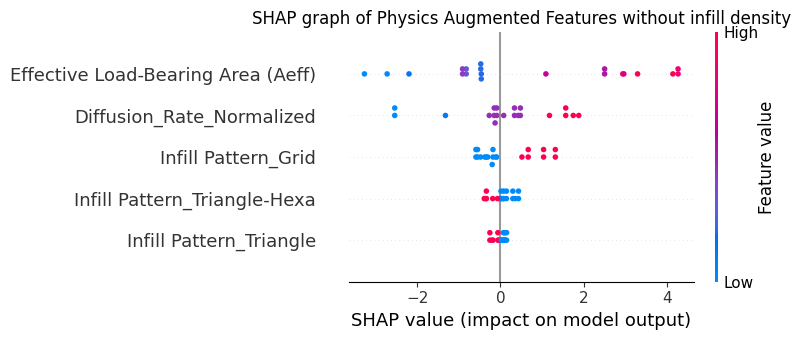

In [44]:
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP Explainer
explainer = shap.TreeExplainer(cat_physics)

# 2. Calculate SHAP values for your test set
# Use the actual physics features dataframe
shap_values = explainer.shap_values(X_test)

# 3. Plot the Summary Plot
plt.figure(figsize=(10, 6))
plt.title('SHAP graph of Physics Augmented Features without infill density')
shap.summary_plot(shap_values, X_test, feature_names=FEATURES_PHYSICS)



In [45]:
# import pandas as pd
# import numpy as np
# from statsmodels.stats.outliers_influence import variance_inflation_factor

# # Use the already defined FEATURES_PHYSICS list and the df_encoded dataframe
# # 1. Prepare your feature matrix (X)
# X = df_encoded[FEATURES_PHYSICS].copy()

# # Add a constant (intercept) as required by statsmodels for VIF calculation
# # This allows the VIF to account for the mean of the features
# X_with_const = X.assign(const=1)

# # 2. Calculate VIF for each feature
# vif_data = pd.DataFrame()
# vif_data["feature"] = X_with_const.columns
# vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
#                    for i in range(len(X_with_const.columns))]

# # Remove the 'const' row for clear analysis
# vif_result = vif_data[vif_data['feature'] != 'const']
# print("Initial VIF Results:\n", vif_result)

# # 3. Implement your dropping logic
# # We extract the VIF value specifically for Infill Density (%)
# infill_vif = vif_result.loc[vif_result['feature'] == 'Infill Density (%)', 'VIF'].values[0]

# if infill_vif > 10:
#     print(f"\n[ACTION] VIF for Infill Density is {infill_vif:.2f} (> 10).")
#     print("Dropping 'Infill Density (%)' to prioritize mechanical 'Aeff'.")
    